<h1>ENSO Teleconnections - Precip - Compare 2 UFS</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
from itertools import product
import numpy as np
from io import BytesIO
from PIL import Image
import scipy
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import oni, stats

import warnings
warnings.filterwarnings('ignore')

<h3>User Configurables</h3>

In [3]:
ufs1_experiment = 'beta1'
ufs2_experiment = 'beta2'

In [4]:
ufs1_var = 'pratesfc'
ufs2_var = 'pratesfc'

In [5]:
time_range = ("1994-01-01", "2020-12-01")
initmonth = 9

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = (0, 1, 2, 3)

In [6]:
# Scale variables for unit-matching
ufs1_scaling_factor = 86400
ufs2_scaling_factor = 86400

In [7]:
# Define a region over which to calculate correlation
# You can ignore region by setting it to None
# region = None
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax': 240.0
}

In [8]:
significance_level = 0.05

In [9]:
# Filter ONI events per specific criteria.
strength = None  # For example, you can set strength = 'Weak', 'Moderate', 'Strong', or 'Very Strong'
oni_threshold = None  # For example, you can set oni_threshold = 3

In [10]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>El Niño Events</h3>

In [11]:
oni.elnino_events  # These have been prerecorded

((1951, 1.2),
 (1952, 0.8),
 (1953, 0.8),
 (1957, 1.8),
 (1958, 0.6),
 (1963, 1.4),
 (1965, 1.9),
 (1968, 1.1),
 (1969, 0.9),
 (1972, 1.8),
 (1976, 0.9),
 (1977, 0.8),
 (1979, 0.6),
 (1982, 2.2),
 (1986, 1.2),
 (1987, 1.7),
 (1991, 1.7),
 (1994, 1.1),
 (1997, 2.4),
 (2002, 1.3),
 (2004, 0.7),
 (2006, 0.94),
 (2009, 1.36),
 (2014, 0.93),
 (2015, 2.64),
 (2018, 0.9),
 (2023, 1.95))

<h3>La Niña Events</h3>

In [12]:
oni.lanina_events  # These have been prerecorded

((1954, -0.9),
 (1955, -1.4),
 (1964, -0.8),
 (1970, -1.4),
 (1971, -0.9),
 (1973, -1.9),
 (1974, -0.8),
 (1975, -1.7),
 (1983, -0.9),
 (1984, -0.9),
 (1988, -1.8),
 (1995, -1.0),
 (1998, -1.6),
 (1999, -1.7),
 (2000, -0.7),
 (2005, -0.85),
 (2007, -1.64),
 (2008, -0.85),
 (2010, -1.64),
 (2011, -1.09),
 (2016, -0.69),
 (2017, -0.97),
 (2020, -1.27),
 (2021, -1.06),
 (2022, -0.99))

<h3>Create ONI objects for each event</h3>

In [13]:
ElNinos = [oni.ONI(event[0], event[1]) for event in oni.elnino_events]
LaNinas = [oni.ONI(event[0], event[1]) for event in oni.lanina_events]

In [14]:
elnino_strengths = [nino.get('strength') for nino in ElNinos]
lanina_strengths = [nina.get('strength') for nina in LaNinas]

In [15]:
collections.Counter(elnino_strengths)

Counter({'Weak': 11, 'Moderate': 7, 'Strong': 6, 'Very Strong': 3})

In [16]:
collections.Counter(lanina_strengths)

Counter({'Weak': 12, 'Strong': 7, 'Moderate': 6})

<h3>Get El Niño / La Niña years per specific criteria</h3>

In [17]:
# El Nino years
elnino_years = []
for nino in ElNinos:
    if strength is not None and nino.get('strength') != strength:
        continue      
    if oni_threshold is not None and nino.get('oni_magnitude') < oni_threshold:
        continue     
    elnino_years.append(nino.get('year'))

# La Nina
lanina_years = []
for nina in LaNinas:
    if strength is not None and nina.get('strength') != strength:
        continue      
    if oni_threshold is not None and nina.get('oni_magnitude') < oni_threshold:
        continue     
    lanina_years.append(nina.get('year'))
    
# Print El Nino years
print("Number of El Nino years: ", len(elnino_years))
for this_year in elnino_years:
    print(this_year, end=' ')
    
print('\n')

# Print La Nina years
print("Number of La Nina years: ", len(lanina_years))
for this_year in lanina_years:
    print(this_year, end=' ')
    

Number of El Nino years:  27
1951 1952 1953 1957 1958 1963 1965 1968 1969 1972 1976 1977 1979 1982 1986 1987 1991 1994 1997 2002 2004 2006 2009 2014 2015 2018 2023 

Number of La Nina years:  25
1954 1955 1964 1970 1971 1973 1974 1975 1983 1984 1988 1995 1998 1999 2000 2005 2007 2008 2010 2011 2016 2017 2020 2021 2022 

In [18]:
# Our model data doesn't go back to year 1950, nor does it reach the present, so what years are remaining?

begin_year = int(time_range[0][0:4])
end_year = int(time_range[1][0:4])

elnino_years_in_data = [y for y in elnino_years if y >= begin_year and y <= end_year]
lanina_years_in_data = [y for y in lanina_years if y >= begin_year and y <= end_year]

print('El Nino in data:')
print(elnino_years_in_data)
print('')
print('La Nina in data:')
print(lanina_years_in_data)

El Nino in data:
[1994, 1997, 2002, 2004, 2006, 2009, 2014, 2015, 2018]

La Nina in data:
[1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2016, 2017, 2020]


In [19]:
# Construct a list of tuples, where each tuple is like (init, lead)
# This is used in the calc_composite_layers() function
elnino_exclude_initleads = []
lanina_exclude_initleads = []

for this_year in range(begin_year, end_year+1):
    this_init = np.datetime64(f'{this_year}-{str(initmonth).zfill(2)}-01')
    
    for this_lead in leads:

        if this_year not in elnino_years_in_data:
            elnino_exclude_initleads.append((this_init, this_lead))
            
        if this_year not in lanina_years_in_data:
            lanina_exclude_initleads.append((this_init, this_lead))

<h3>Read in datasets and do some preprocessing</h3>

In [21]:
filename1 = f"experiments/{ufs1_experiment}/reforecast/{str(initmonth).zfill(2)}/atm_monthly.zarr"
data_reader1 = dr.getDataReader(datasource='UFS', filename=filename1, model='atm')

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta1/reforecast/09/atm_monthly.zarr


In [22]:
filename2 = f"experiments/{ufs2_experiment}/reforecast/{str(initmonth).zfill(2)}/atm_monthly.zarr"
data_reader2 = dr.getDataReader(datasource='UFS', filename=filename2, model='atm')

Reading data from s3://noaa-oar-sfsdev-pds/experiments/beta2/reforecast/09/atm_monthly.zarr


In [25]:
ufs1_ds = data_reader1.retrieve(var=ufs1_var,
                                time=time_range,
                                initmonths=initmonth,
                                lead=(min(leads), max(leads)),
                                ens_avg=True)

Taking Ensemble Average


In [26]:
ufs2_ds = data_reader2.retrieve(var=ufs2_var,
                                time=time_range,
                                initmonths=initmonth,
                                lead=(min(leads), max(leads)),
                                ens_avg=True)

Taking Ensemble Average


In [27]:
# Scale fields.
ufs1_ds = ufs1_ds * ufs1_scaling_factor                                                                          
ufs2_ds = ufs2_ds * ufs2_scaling_factor

In [28]:
data_reader1.update(ds=ufs1_ds)
data_reader2.update(ds=ufs2_ds)

Dataset updated.
Dataset updated.


In [33]:
ds1_elnino_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                    var=ufs1_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=elnino_exclude_initleads)

ds1_lanina_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                    var=ufs1_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=lanina_exclude_initleads)

ds2_elnino_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs2_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=elnino_exclude_initleads)

ds2_lanina_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                    var=ufs2_var,
                                                    statistics=['anomaly'],
                                                    exclude_initleads=lanina_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


<p>
---------------------------------------------------------------<br>
We now have 4 datasets of statistics:<br>
<br>
ds1_elnino_statistics<br>
ds1_lanina_statistics<br>
ds2_elnino_statistics<br>
ds2_lanina_statistics<br>
---------------------------------------------------------------
</p>

In [34]:
# Verify that phase-events are properly sorted.
if len(set(list(product(ds1_elnino_statistics.init.values, ds1_elnino_statistics.lead.values))) &\
    set(list(product(ds1_lanina_statistics.init.values, ds1_lanina_statistics.lead.values)))) > 0:
    raise ValueError('Duplicate phases identified between positive and negative phases for dataset 1')
    
if len(set(list(product(ds2_elnino_statistics.init.values, ds2_elnino_statistics.lead.values))) &\
    set(list(product(ds2_lanina_statistics.init.values, ds2_lanina_statistics.lead.values)))) > 0:
    raise ValueError('Duplicate phases identified between positive and negative phases for dataset 2')

<h3>Run t-tests</h3>

In [35]:
# Get position of init and lead axes
dims = list(ds1_elnino_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [36]:
# EL NINO
anomaly_tstatistic_elnino, anomaly_pvalue_elnino =\
    scipy.stats.ttest_ind(a=ds1_elnino_statistics['anomaly'].values,
                          b=ds2_elnino_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# LA NINA
anomaly_tstatistic_lanina, anomaly_pvalue_lanina =\
    scipy.stats.ttest_ind(a=ds1_lanina_statistics['anomaly'].values,
                          b=ds2_lanina_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

In [37]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_elnino': (('lat', 'lon'), anomaly_pvalue_elnino),
        'anomaly_pvalue_lanina': (('lat', 'lon'), anomaly_pvalue_lanina)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h1>Anomaly</h1>

In [38]:
# This is the DataArray for the Composite
ds1_elnino_composite = ds1_elnino_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_lanina_composite = ds1_lanina_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_elnino_composite = ds2_elnino_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_lanina_composite = ds2_lanina_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
elnino_ds2_minus_ds1 = ds2_elnino_composite - ds1_elnino_composite
lanina_ds2_minus_ds1 = ds2_lanina_composite - ds1_lanina_composite

# Calculate Correlations
elnino_corr = xr.corr(ds1_elnino_composite, ds2_elnino_composite).values.item()
lanina_corr = xr.corr(ds1_lanina_composite, ds2_lanina_composite).values.item()

# Calculate Correlations over a smaller region
if region is not None:
    
    # latitudes are ordered 90 to -90
    lat_slice = slice(region['latmax'], region['latmin'])
    lon_slice = slice(region['lonmin'], region['lonmax'])
    
    elnino_corr_region = xr.corr(ds1_elnino_composite.sel(lat=lat_slice, lon=lon_slice),
                                 ds2_elnino_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()
    
    lanina_corr_region = xr.corr(ds1_lanina_composite.sel(lat=lat_slice, lon=lon_slice),
                                 ds2_lanina_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()

<h5>Make labels for the plots</h5>

In [39]:
elnino_event_years = list(ds1_elnino_statistics.groupby('init.year').groups.keys())
lanina_event_years = list(ds1_lanina_statistics.groupby('init.year').groups.keys())

# Convert every year into 'YY for compactness.
elnino_event_years = [f"'{str(y)[2:4]}" for y in elnino_event_years]
lanina_event_years = [f"'{str(y)[2:4]}" for y in lanina_event_years]

elnino_event_years = f"Events: {' '.join([f'{y}' for y in elnino_event_years])}"  # convert to string
lanina_event_years = f"Events: {' '.join([f'{y}' for y in lanina_event_years])}"  # convert to string

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
elnino_corr_label = f'corr: {elnino_corr:.2f}'
lanina_corr_label = f'corr: {lanina_corr:.2f}'

if region is not None:
    elnino_corr_label = f'{elnino_corr_label}\nregion: {elnino_corr_region:.2f}'
    lanina_corr_label = f'{lanina_corr_label}\nregion: {lanina_corr_region:.2f}'

<h3>Generate figures</h3>

In [40]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()
buffer7 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'mm day-1',
               'cmap': 'BrBG',
               'topleft_label': initlead_label, 
               'region': region,
               'dpi': 200}

plot1 = stats.plot_composite(da = ds1_elnino_composite,
                             title=f'(a) SFS-{ufs1_experiment} Precipitation Anomaly (El Niño)',
                             vmin=-6, vmax=6,
                             subtitle=elnino_event_years, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = stats.plot_composite(da = ds1_lanina_composite,
                             title=f'(b) SFS-{ufs1_experiment} Precipitation Anomaly (La Niña)',
                             vmin=-6, vmax=6,
                             subtitle=lanina_event_years, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = stats.plot_composite(da = ds2_elnino_composite,
                             title=f'(c) SFS-{ufs2_experiment} Precipitation Anomaly (El Niño)',
                             vmin=-6, vmax=6,
                             subtitle=elnino_event_years, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = stats.plot_composite(da = ds2_lanina_composite,
                             title=f'(d) SFS-{ufs2_experiment} Precipitation Anomaly (La Niña)',
                             vmin=-6, vmax=6,
                             subtitle=lanina_event_years, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = stats.plot_composite(da = elnino_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_elnino'],
                             shading_threshold = significance_level,
                             title=f'(e) SFS-{ufs2_experiment} minus SFS-{ufs1_experiment} Precipitation Anomaly (El Niño)',
                             vmin=-4, vmax=4,
                             subtitle=elnino_event_years,
                             bottomright_label=elnino_corr_label,
                             **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = stats.plot_composite(da = lanina_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_lanina'],
                             shading_threshold = significance_level,
                             title=f'(f) SFS-{ufs2_experiment} minus SFS-{ufs1_experiment} Precipitation Anomaly (La Niña)',
                             vmin=-4, vmax=4,
                             subtitle=lanina_event_years,
                             bottomright_label=lanina_corr_label,
                             **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

caption_text = f"""Composites of precipitation monthly anomaly. El Niño (left), La Niña (right).
Panels (a) and (b) show SFS-{ufs1_experiment}; Panels (c) and (d) show SFS-{ufs2_experiment}; Panels (e) and (f) show SFS-{ufs2_experiment} minus SFS-{ufs1_experiment}.
Dotted regions are statistically significant at 95%.  For (e) and (f), the lower-right corner shows pattern
correlation between model and verification for the entire domain and for the ENSO region 5S-5N, 170W-120W."""

plt.figure(figsize=(20, 1), facecolor='white')
plt.text(0.15, 0.5,
    caption_text,
    family='serif',
    fontsize=15,
    color='black',
    ha='left',
    va='center')

plt.axis('off')

plt.savefig(buffer7, format='png', bbox_inches='tight')

<h3>Construct 3 row x 2 column multi-paneled image</h3>

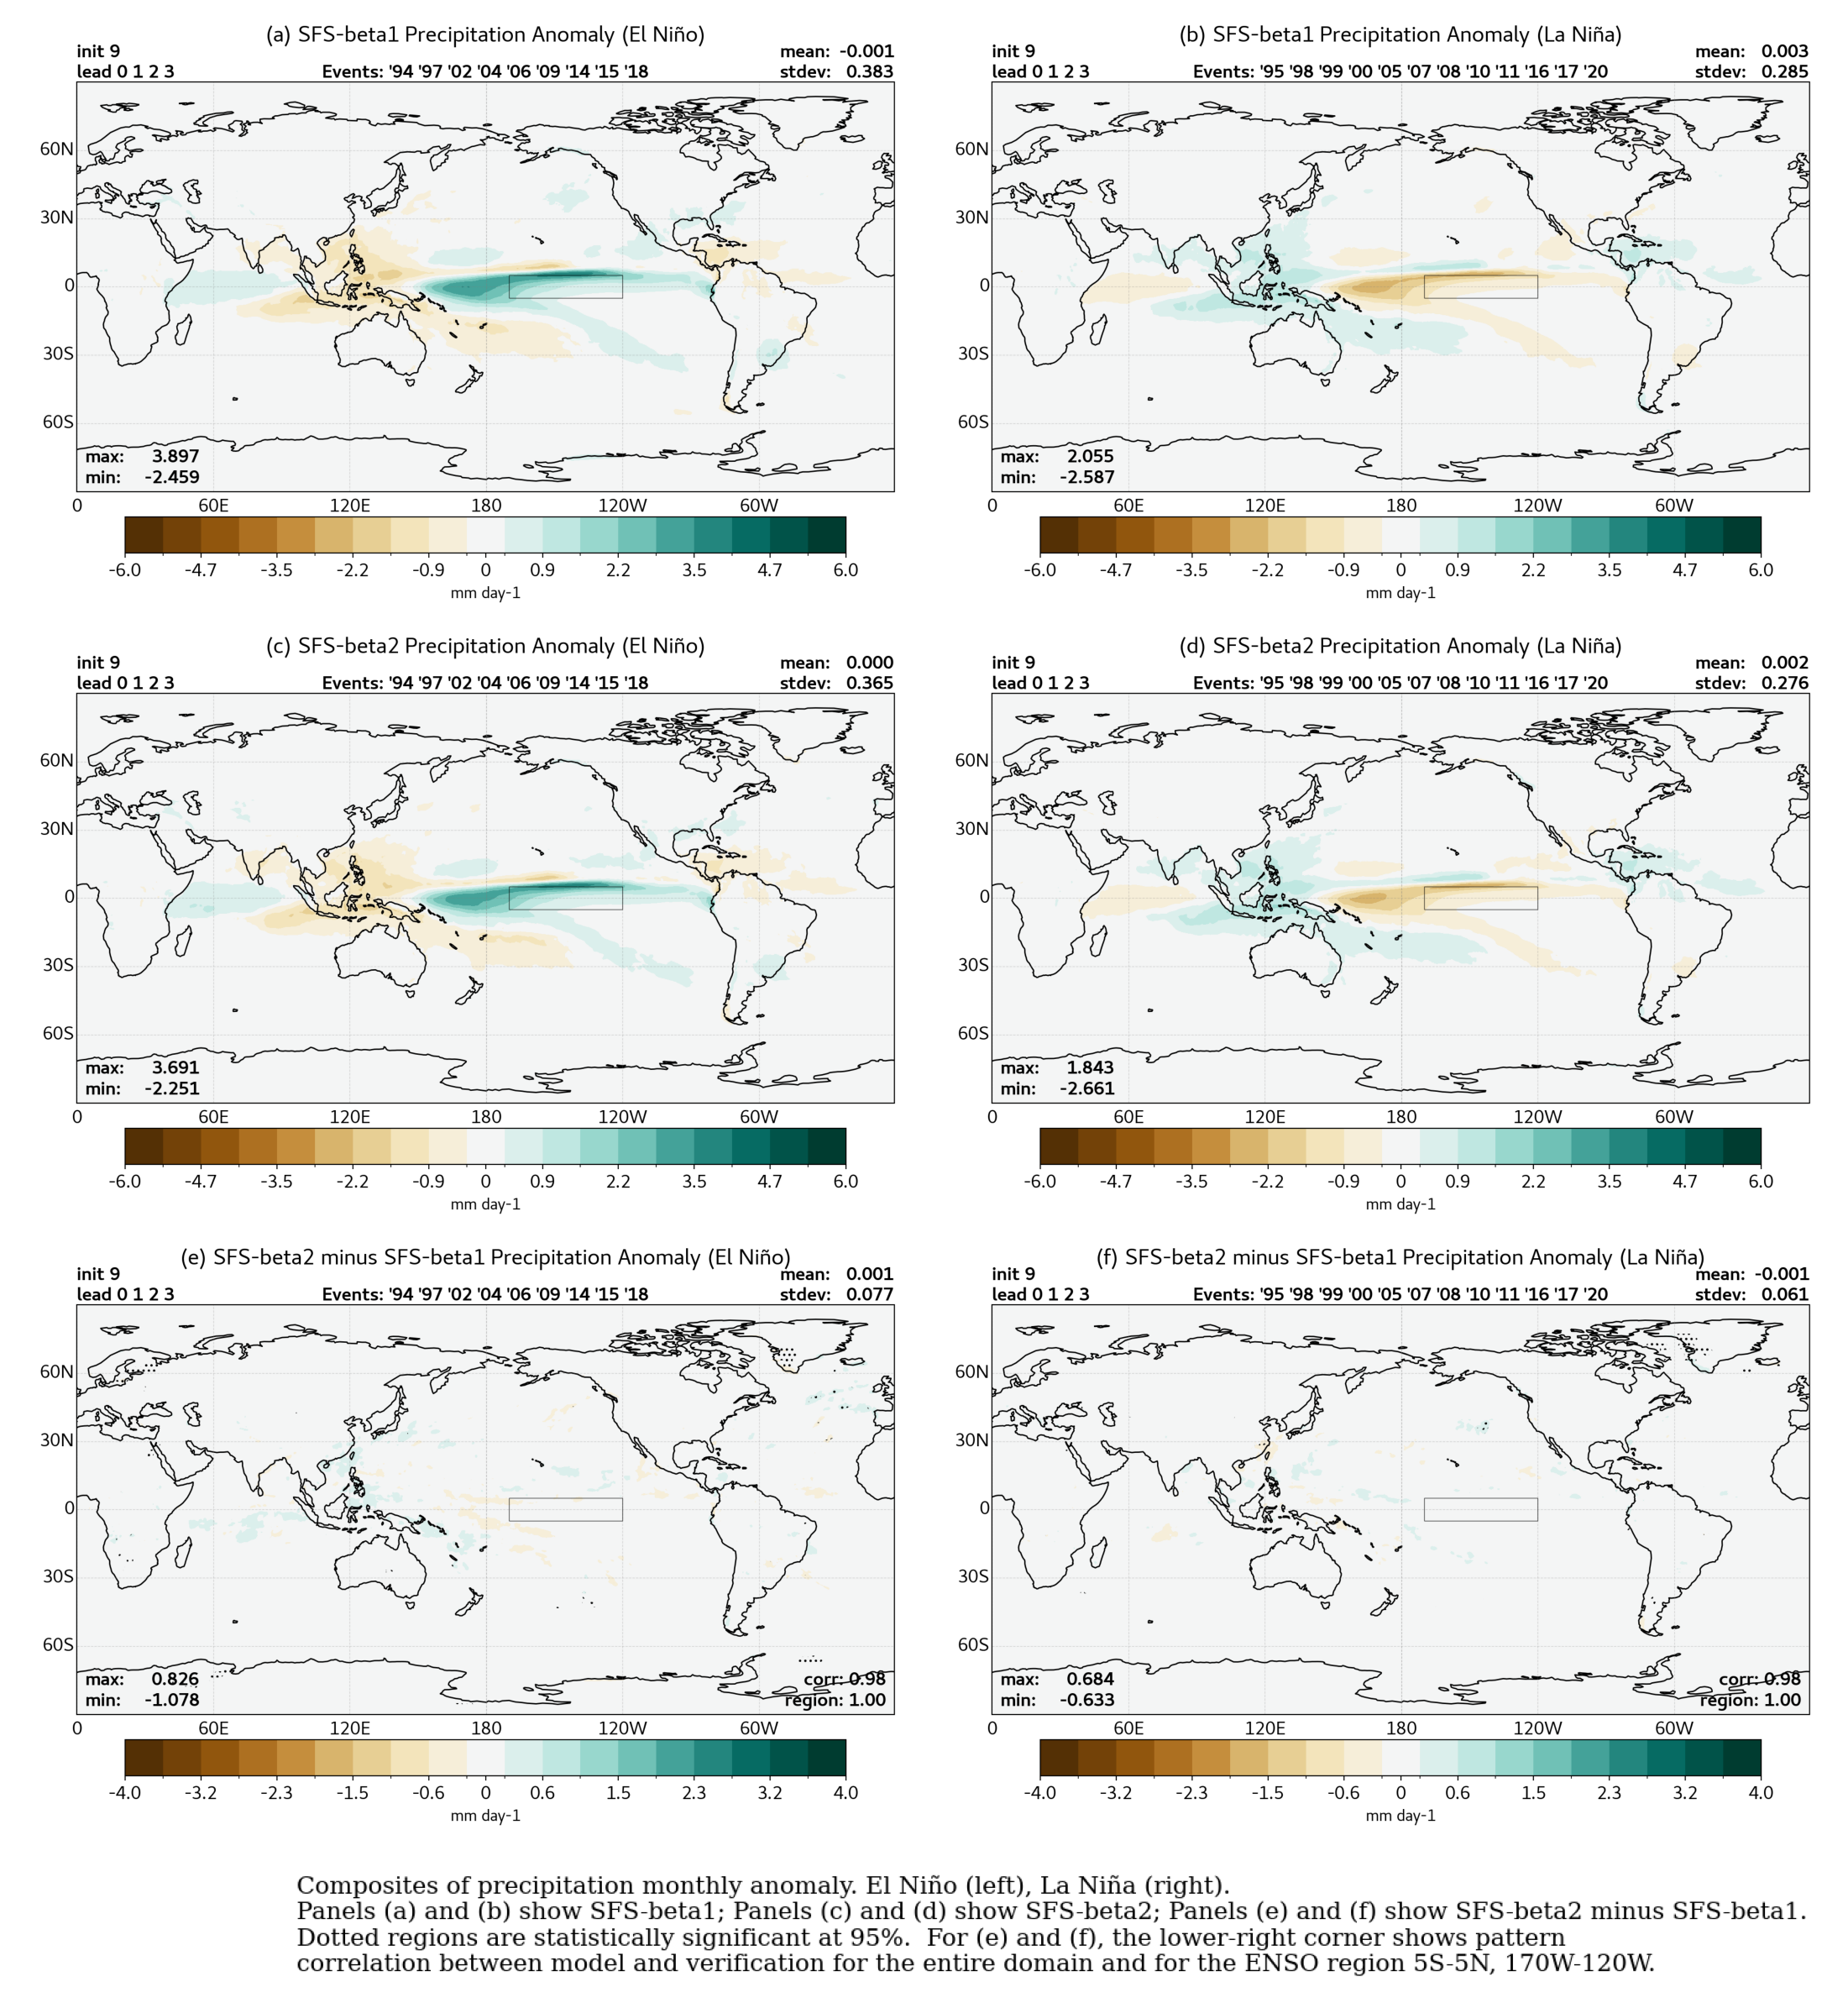

In [41]:
# Layout for mosaic figure
layout = [
    ['A', 'B'],
    ['C', 'D'],
    ['E', 'F'],
    ['G', 'G']]

fig, axd = plt.subplot_mosaic(layout,
                              figsize=(11, 12),
                              gridspec_kw={'height_ratios': [4, 4, 4, 1]},
                              dpi=200)
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)
image7 = Image.open(buffer7)

# fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axd['A'].imshow(image1)
axd['A'].axis('off')

axd['B'].imshow(image2)
axd['B'].axis('off')

axd['C'].imshow(image3)
axd['C'].axis('off')

axd['D'].imshow(image4)
axd['D'].axis('off')

axd['E'].imshow(image5)
axd['E'].axis('off')

axd['F'].imshow(image6)
axd['F'].axis('off')

axd['G'].imshow(image7)
axd['G'].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=0.5)
plt.show()

In [42]:
del buffer1, buffer2, buffer3, buffer4, buffer5, buffer6
del image1, image2, image3, image4, image5, image6
del plot1, plot2, plot3, plot4, plot5, plot6, plt
gc.collect()

39688